In [10]:
# imports

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
train_df = pd.read_csv("/kaggle/input/house-rent-prediction-dataset/House_Rent_Dataset.csv")

In [12]:
train_df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [13]:
train_df.isnull().sum().sum()

0

In [14]:
train_df.nunique()

Posted On              81
BHK                     6
Rent                  243
Size                  615
Floor                 480
Area Type               3
Area Locality        2235
City                    6
Furnishing Status       3
Tenant Preferred        3
Bathroom                8
Point of Contact        3
dtype: int64

In [15]:
train_df.duplicated().sum()

0

## Categorical and numerical

In [16]:
count = 0
col_num = []
col_cat = []

for col in train_df.columns:
    if (train_df[col].dtype) in ['float64', 'int64']:
        col_num.append(col)
        count+=1
    elif train_df[col].dtype == 'object':
        col_cat.append(col)
    else:
        print(f"{col} is nor num or cat")

print(f"{count} columns are numerical, and {len(train_df.columns) - count - 2} are categorical, except 'id' & 'diagnosed_diabetes'")        

4 columns are numerical, and 6 are categorical, except 'id' & 'diagnosed_diabetes'


## Boxplot

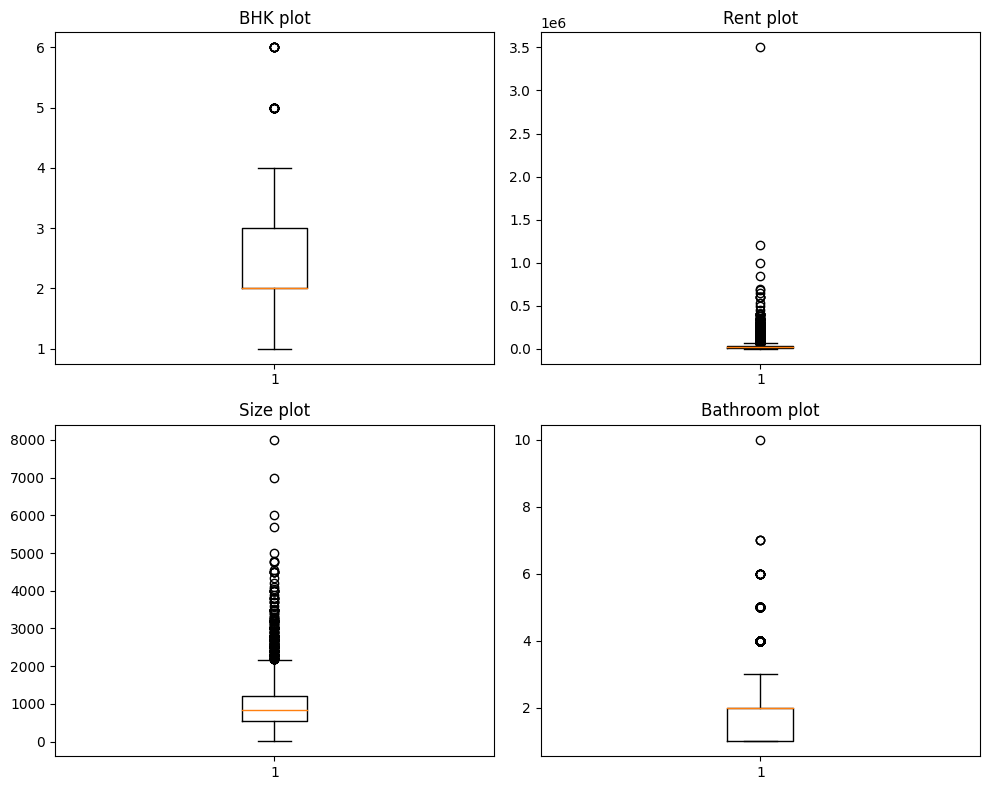

In [21]:
plt.figure(figsize=(10, 8))
i = 1

for col in col_num:
    plt.subplot(2, 2, i)
    plt.boxplot(train_df[f"{col}"])
    plt.title(f"{col} plot")
    i+=1

plt.tight_layout()
plt.show()

## Histograms

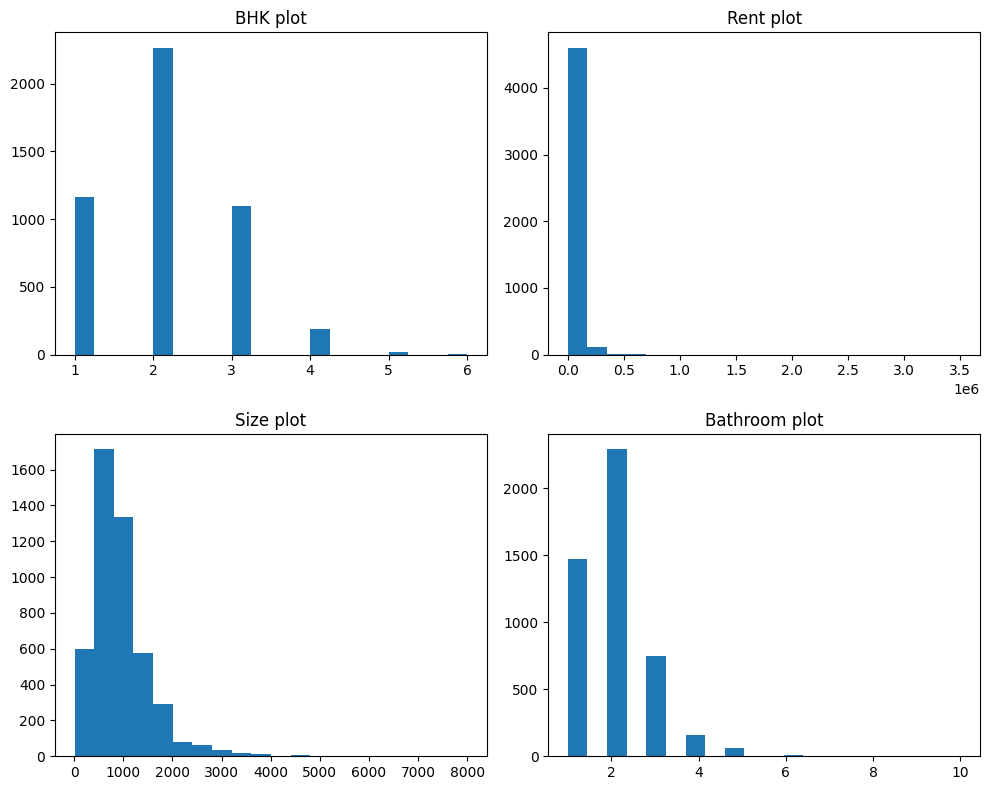

In [22]:
plt.figure(figsize=(10, 8))
i = 1

for col in col_num:
    plt.subplot(2, 2, i)
    plt.hist(train_df[f"{col}"], bins=20)
    plt.title(f"{col} plot")
    i+=1

plt.tight_layout()
plt.show()

## Density plot (KDE)

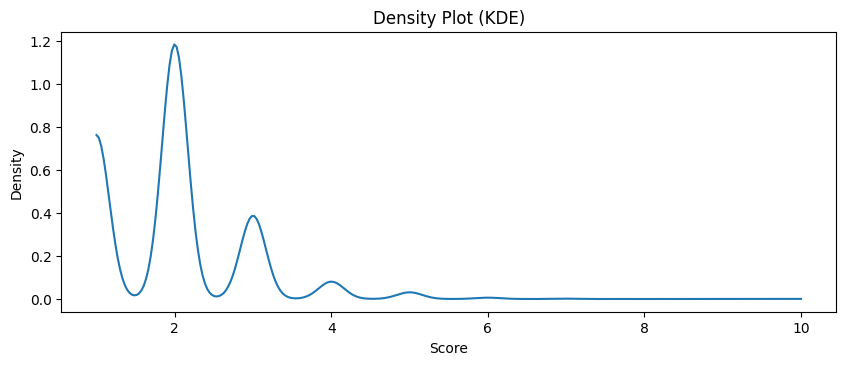

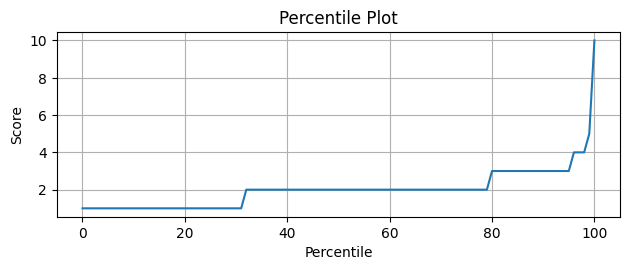

In [23]:
from scipy.stats import gaussian_kde

data = train_df[f"{col_num[3]}"]

density = gaussian_kde(data)
x = np.linspace(data.min(), data.max(), 300)

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(x, density(x))
plt.title("Density Plot (KDE)")
plt.xlabel("Score")
plt.ylabel("Density")
plt.show()

percentile = np.arange(0, 101)
values = np.percentile(data, percentile)

plt.subplot(2, 1, 2)
plt.plot(percentile, values)
plt.title("Percentile Plot")
plt.xlabel("Percentile")
plt.ylabel("Score")
plt.grid(True)

plt.tight_layout()
plt.show()

## Bar Chart

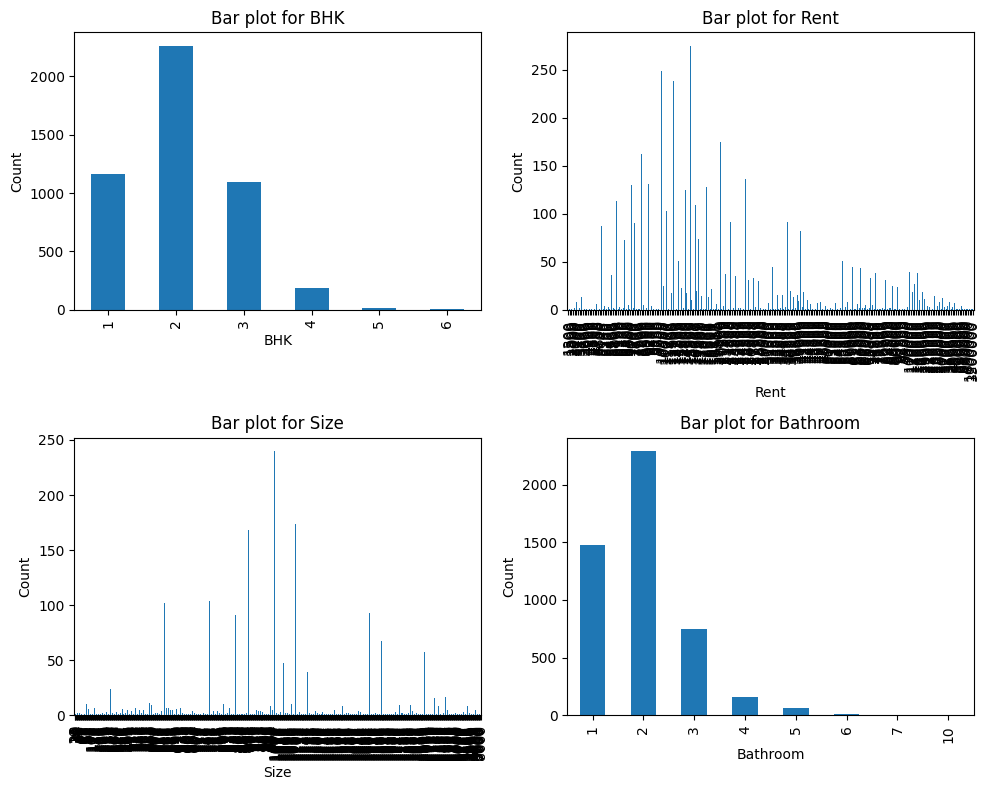

In [24]:
plt.figure(figsize=(10, 8))
i=1

for col in col_num:
    plt.subplot(2, 2, i)
    train_df[f'{col}'].value_counts().sort_index().plot(kind='bar')
    plt.title(f'Bar plot for {col}')
    plt.xlabel(f'{col}')
    plt.ylabel('Count')
    i+=1

plt.tight_layout()
plt.show()

## Correlation/Heatmaps

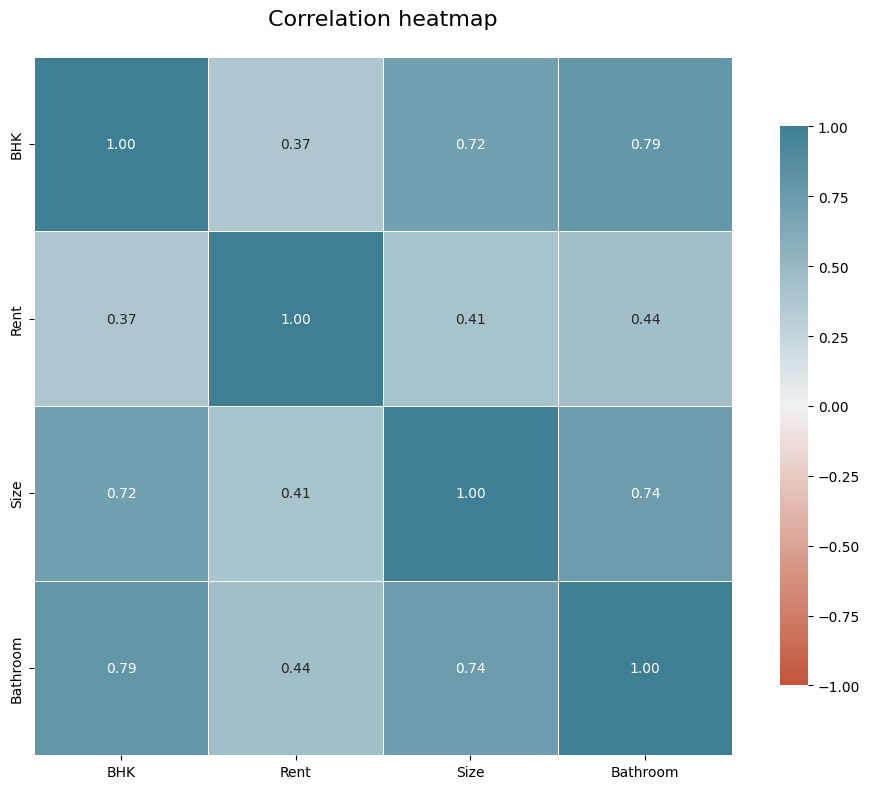

In [26]:
plt.figure(figsize=(10, 8))

sns.heatmap(train_df[col_num].corr(),
            vmin=-1, vmax=1,
            cmap=sns.diverging_palette(20, 220, as_cmap=True),
            # cmap="coolwarm",
            annot=True,
            square=True,
            linewidth=0.5,
            fmt=".2f",
            cbar_kws={"shrink": 0.8},
           )

plt.title('Correlation heatmap\n',
          fontsize=16,
          # weight="bold",
         )
plt.tight_layout()
plt.show()

## Scatter plots

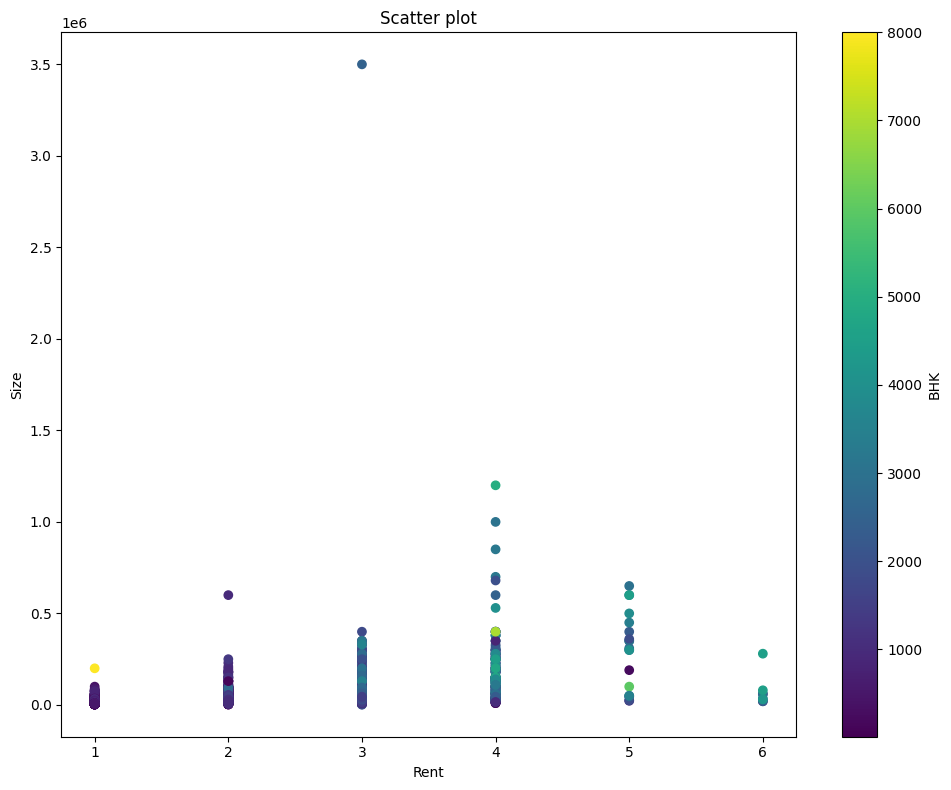

In [28]:
plt.figure(figsize=(10, 8))

plt.scatter(train_df[f"{col_num[0]}"],
            train_df[f"{col_num[1]}"],
            c=train_df[f"{col_num[2]}"]
)

plt.colorbar(label=col_num[0])
plt.title('Scatter plot')
plt.xlabel(f'{col_num[1]}')
plt.ylabel(f'{col_num[2]}')
plt.tight_layout()
plt.show()

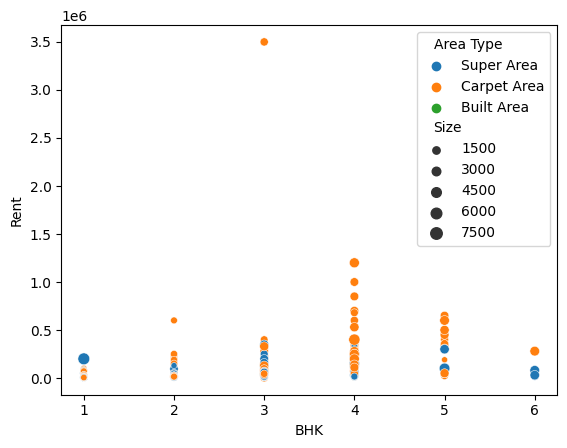

In [31]:
sns.scatterplot(data=train_df,
                x=col_num[0],
                y=col_num[1],
                hue=col_cat[2],
                size=col_num[2],
               )

plt.show()

## Pairplots

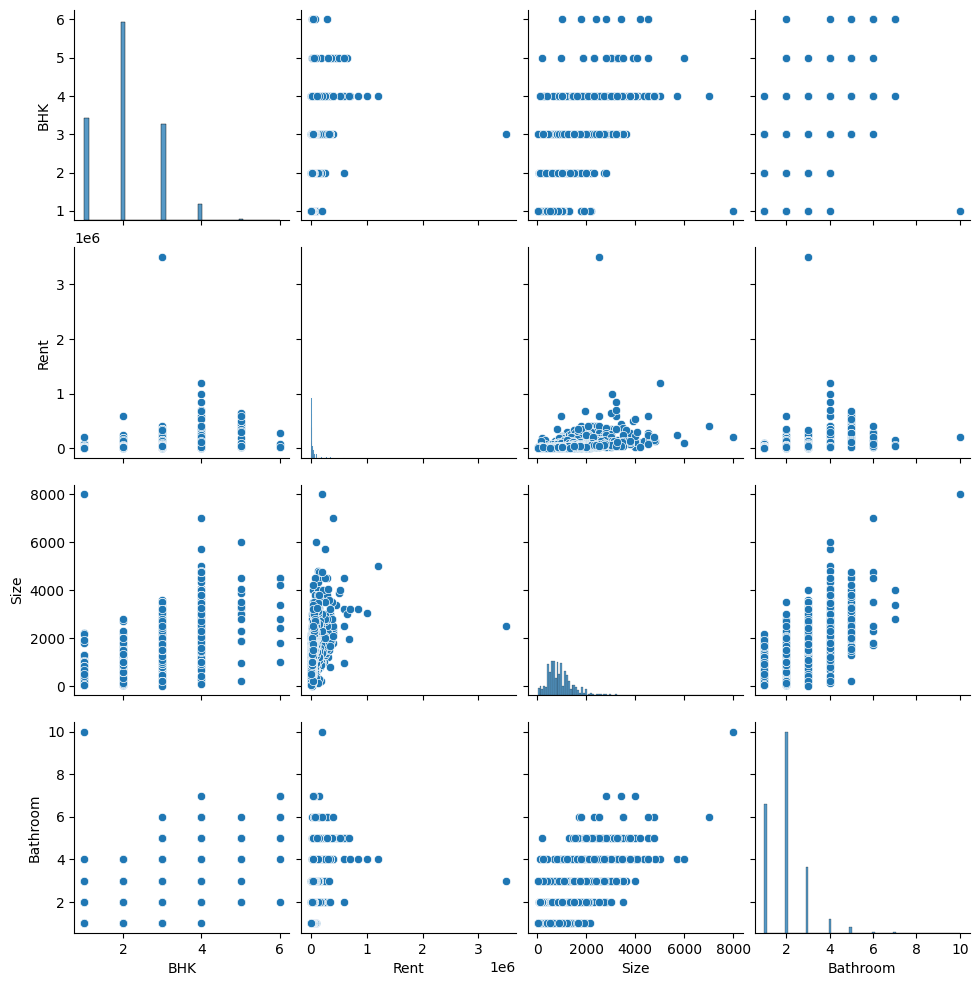

In [37]:
import warnings
warnings.filterwarnings("ignore")

sns.pairplot(train_df,
             vars=col_num,
             # hue=col_cat,
            )
plt.show()

## Regression lines

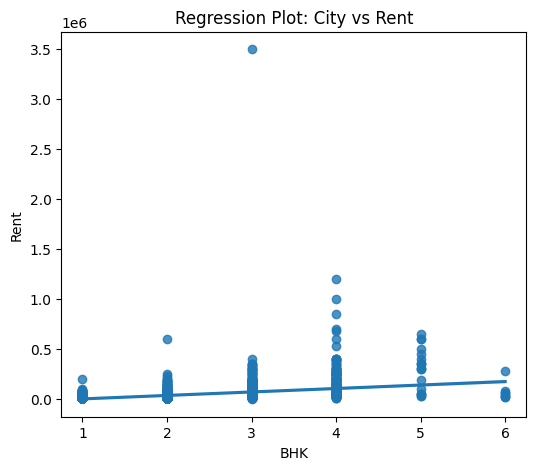

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.regplot(data=train_df, x='BHK', y='Rent')
plt.title("Regression Plot: City vs Rent")
plt.show()

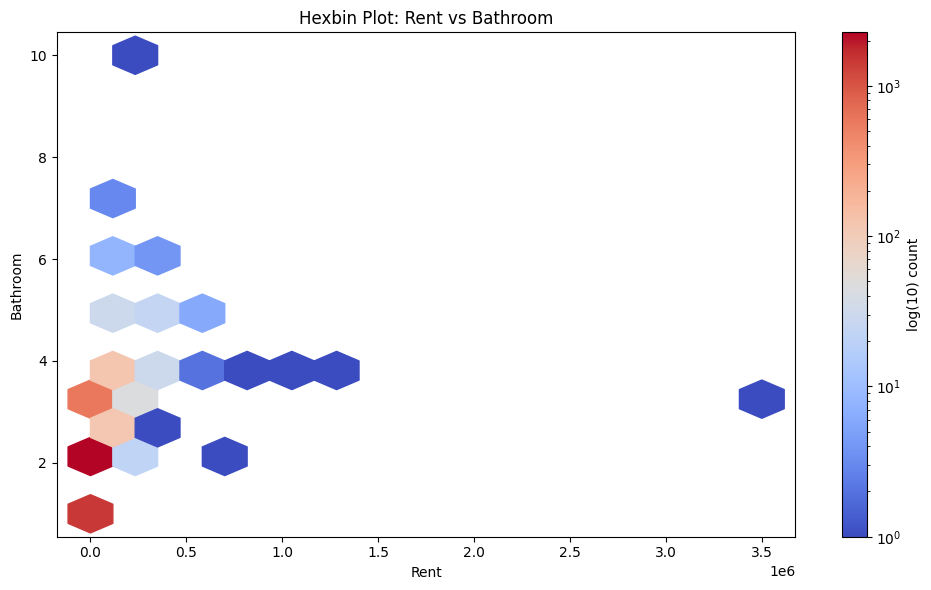

In [54]:
plt.figure(figsize=(10, 6))

plt.hexbin(
    train_df[col_num[1]],
    train_df[col_num[3]],
    gridsize=15,
    cmap="coolwarm",
    bins="log",               # this sets log, remove it to make it normal
)

plt.colorbar(label="log(10) count")
plt.xlabel(col_num[1])
plt.ylabel(col_num[3])
plt.title(f"Hexbin Plot: {col_num[1]} vs {col_num[3]}")

plt.tight_layout()
plt.show()

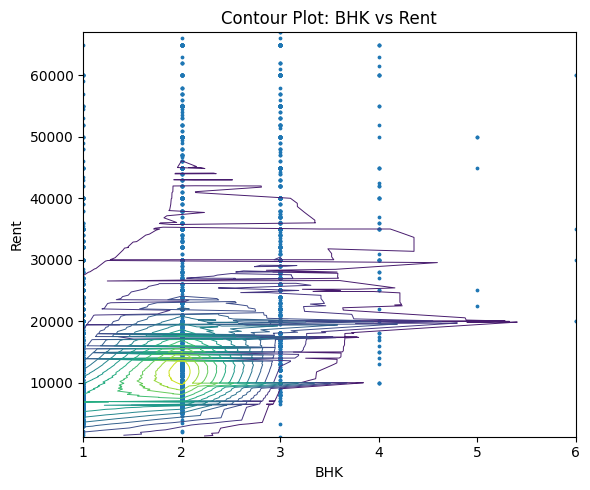

In [66]:
from scipy.stats import gaussian_kde

x = train_df[col_num[0]]
y = train_df[col_num[1]]

Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1

mask = (y >= Q1 - 1.5 * IQR) & (y <= Q3 + 1.5 * IQR)
x_filt = x[mask]
y_filt = y[mask]

xy = np.vstack([x_filt, y_filt])
z = gaussian_kde(xy)(xy)

plt.figure(figsize=(6, 5))
plt.tricontour(x_filt,y_filt, z, levels=14, linewidths=0.7)
plt.scatter(x_filt, y_filt, s=3)
plt.xlabel(col_num[0])
plt.ylabel(col_num[1])
plt.title(f"Contour Plot: {col_num[0]} vs {col_num[1]}")
plt.tight_layout()
plt.show()

## Violin plots

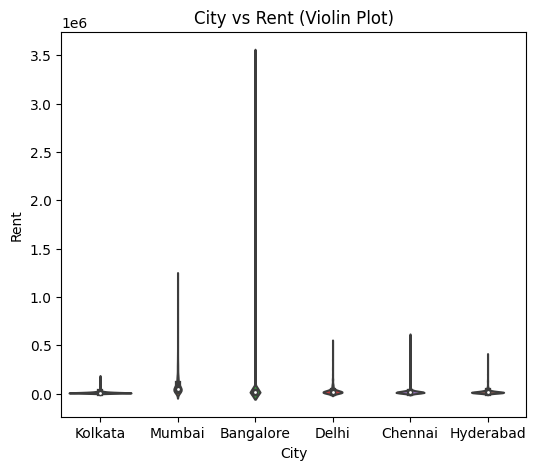

In [70]:
plt.figure(figsize=(6,5))
sns.violinplot(x=train_df['City'], y=train_df['Rent'])
plt.title("City vs Rent (Violin Plot)")
plt.show()


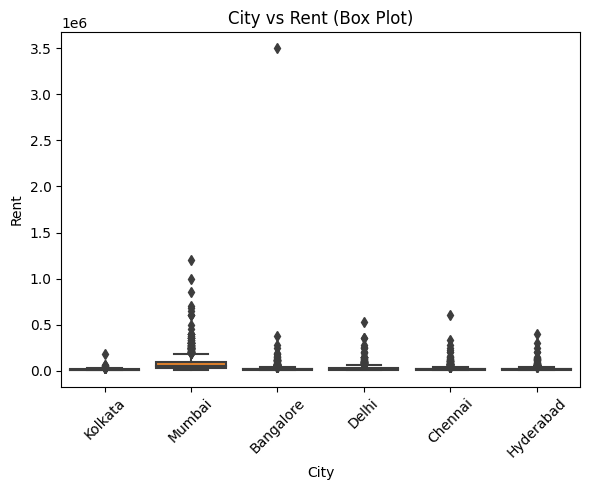

In [76]:
plt.figure(figsize=(6,5))

sns.boxplot(data=train_df, x='City', y='Rent')
plt.title("City vs Rent (Box Plot)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Countplots

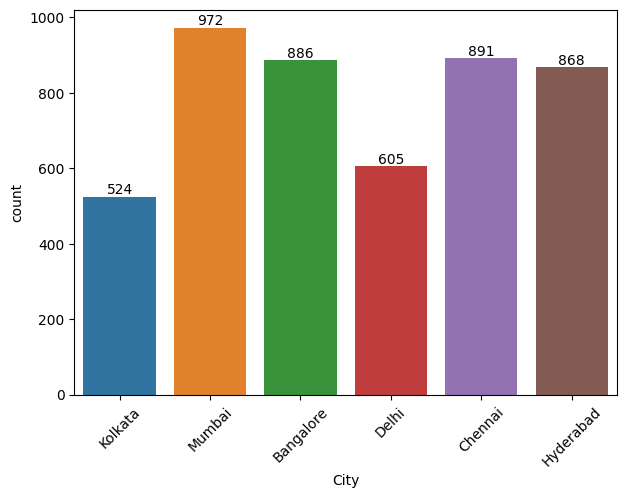

In [79]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=train_df, x='City')

for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.xticks(rotation=45)
plt.show()
